In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [74]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [60]:
from utiles_func import unwrap_failure_type

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
pd.__version__

'2.3.3'

### Phase 1: Load the data

In [4]:
df = pd.read_pickle("../raw_data/wm811k/LSWMD.pkl")

#### Explore the dataset

In [5]:
df.shape

(811457, 6)

In [12]:
df.columns

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

In [6]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [63]:
df.waferMap[0].shape

(45, 48)

In [11]:
print("Unique values:", sorted(set(df.waferMap[0].ravel())))

Unique values: [np.uint8(0), np.uint8(1), np.uint8(2)]


In [15]:
df.failureType

0              [[none]]
1              [[none]]
2              [[none]]
3              [[none]]
4              [[none]]
              ...      
811452    [[Edge-Ring]]
811453     [[Edge-Loc]]
811454    [[Edge-Ring]]
811455               []
811456               []
Name: failureType, Length: 811457, dtype: object

In [54]:
df['Label'] = df.failureType.apply(unwrap_failure_type)

In [55]:
df.Label.unique()

array(['none', 'Loc', None, 'Edge-Loc', 'Center', 'Edge-Ring', 'Scratch',
       'Random', 'Near-full', 'Donut'], dtype=object)

In [61]:
df.Label = df.Label.replace({'none': 'None'})

In [57]:
df.Label.unique()

array(['None', 'Loc', None, 'Edge-Loc', 'Center', 'Edge-Ring', 'Scratch',
       'Random', 'Near-full', 'Donut'], dtype=object)

In [62]:
df.Label.value_counts(dropna=False)

Label
None         638507
None         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [ ]:
shape_set = set()
shape_distribution = {}
for i in range(len(df.waferMap)):
    if df.waferMap[i].shape not in shape_set:
        shape_distribution[df.waferMap[i].shape] = 1
    else:
        shape_distribution[df.waferMap[i].shape] += 1
    shape_set.add(df.waferMap[i].shape)

In [72]:
df_shape_distribution = pd.DataFrame(list(shape_distribution.items()), columns=['Shape', 'Count'])

In [73]:
df_shape_distribution

,Shape,Count
0,"(45, 48)",621
1,"(53, 58)",1212
2,"(26, 26)",30078
3,"(70, 58)",24
4,"(107, 183)",24
...,...,...
627,"(15, 3)",1
628,"(21, 17)",1
629,"(27, 15)",1
630,"(18, 44)",1


In [76]:
class_names = list(df.Label.unique())
class_names

['None',
 'Loc',
 None,
 'Edge-Loc',
 'Center',
 'Edge-Ring',
 'Scratch',
 'Random',
 'Near-full',
 'Donut']

In [77]:
example_map = (
    df.loc[df["Label"].eq(class_names[4])]
    .sample(n=1, random_state=42)
    .iloc[0]
)

In [79]:
wafer_map = example_map["waferMap"]

In [82]:
wafer_colors = ListedColormap([
    "#f2efe8",  # 0: background
    "#6294ba",  # 1: good die
    "#d76741"   # 2: failed die
])

wafer_norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    wafer_colors.N
)

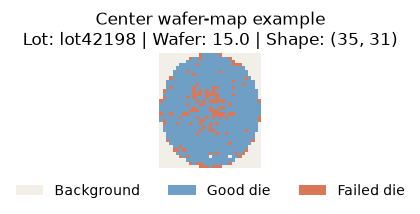

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.imshow(
    wafer_map,
    cmap=wafer_colors,
    norm=wafer_norm,
    interpolation="nearest",
    aspect="equal"
)

ax.set_title(
    f"{class_names[4]} wafer-map example\n"
    f"Lot: {example_map['lotName']} | "
    f"Wafer: {example_map['waferIndex']} | "
    f"Shape: {wafer_map.shape}"
)

ax.axis("off")

legend_items = [
    Patch(facecolor="#f2efe8", label="Background"),
    Patch(facecolor="#6f9fc4", label="Good die"),
    Patch(facecolor="#d97757", label="Failed die")
]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()